## Лабораторная работа №2
### Виртуальный датчик для контроля процесса обжига в печи
#### Прудникова Анастасия 214


### 2.1. Разведочный анализ данных (EDA)

In [1]:
# Основные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели и метрики
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Чтение данных
data = pd.read_csv('data_train.csv')
target = pd.read_csv('target_train.csv')

data['datetime'] = pd.to_datetime(data['datetime'])
target['Дата'] = pd.to_datetime(target['Дата'])

In [3]:
# Анализ пропущенных данных
missing = data.isna().mean().sort_values()
print(missing)

datetime        0.000000
telemetry_11    0.000050
telemetry_10    0.000050
telemetry_9     0.000050
telemetry_8     0.000050
telemetry_6     0.000050
telemetry_7     0.000050
telemetry_3     0.000050
telemetry_2     0.000050
telemetry_1     0.000050
telemetry_0     0.000053
telemetry_5     0.000053
telemetry_4     0.000416
telemetry_14    0.993434
telemetry_12    0.993434
telemetry_13    0.993434
telemetry_15    0.993434
dtype: float64


telemetry_0-11 почти без пропусков

telemetry_12-15 почти полностью пустые, исключим их, чтобы удалить лишний шум и снизить вероятность переобучения.

In [4]:
data = data.drop(columns=['telemetry_12','telemetry_13','telemetry_14','telemetry_15'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319546 entries, 0 to 319545
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      319546 non-null  datetime64[ns]
 1   telemetry_0   319529 non-null  float64       
 2   telemetry_1   319530 non-null  float64       
 3   telemetry_2   319530 non-null  float64       
 4   telemetry_3   319530 non-null  float64       
 5   telemetry_4   319413 non-null  float64       
 6   telemetry_5   319529 non-null  float64       
 7   telemetry_6   319530 non-null  float64       
 8   telemetry_7   319530 non-null  float64       
 9   telemetry_8   319530 non-null  float64       
 10  telemetry_9   319530 non-null  float64       
 11  telemetry_10  319530 non-null  float64       
 12  telemetry_11  319530 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 31.7 MB


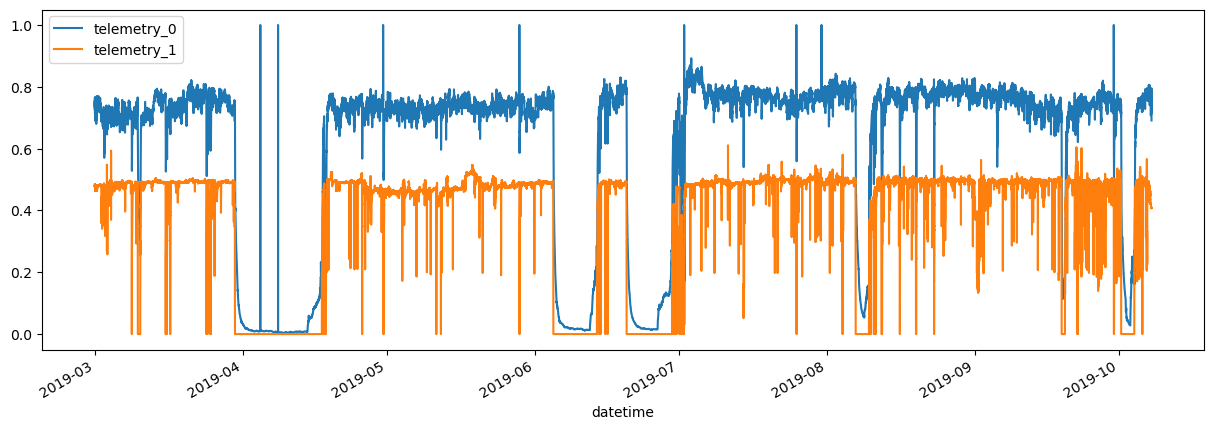

In [5]:
# Визуальный анализ телеметрии (тренды, сезонность, выбросы)
data.set_index('datetime')[['telemetry_0','telemetry_1']].plot(figsize=(15,5))
plt.show()

- Наблюдаются колебания значений - процесс нестатичен
- Присутствуют резкие скачки - возможные выбросы или изменения режима печи
- Видна слабая цикличность - возможна суточная или технологическая периодичность

Выбросы:

- Могут соответствовать аварийным режимам
- Нельзя удалять все выбросы, так как они физически значимы

Целевая переменная:
                 Дата    target
0 2019-03-13 17:00:00  0.123711
1 2019-03-13 21:00:00  0.319588
2 2019-03-14 01:00:00  0.255155
3 2019-03-14 05:00:00  0.319588
4 2019-03-14 09:00:00  0.159794

Распределение концентрации:


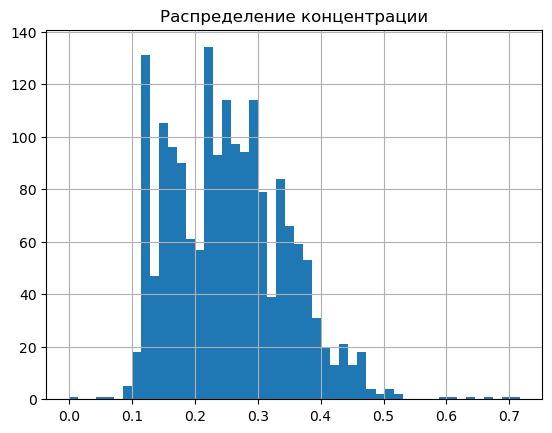


Частота замеров:


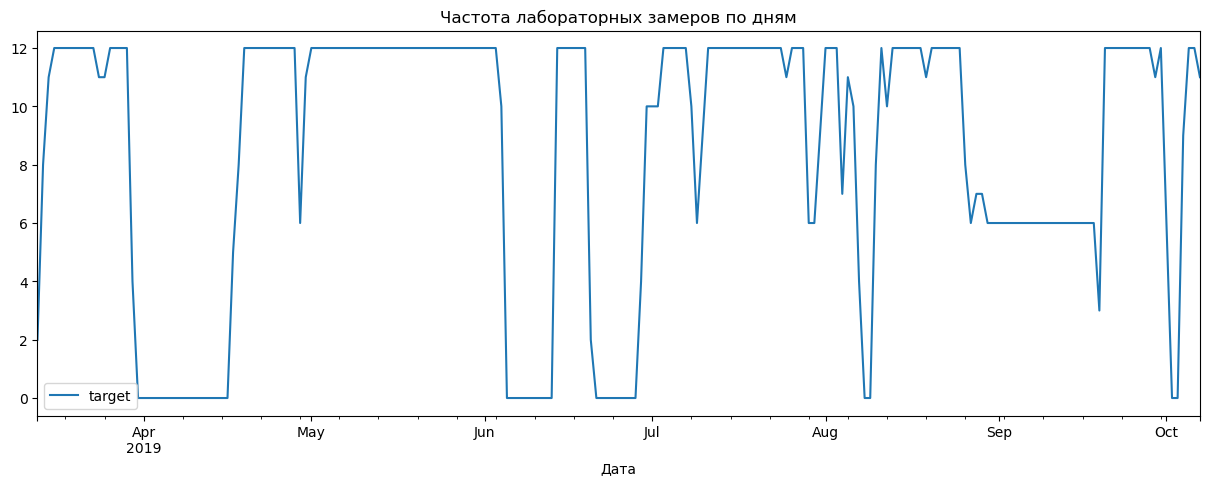


Задержки замеров:
count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: time_diff, dtype: float64


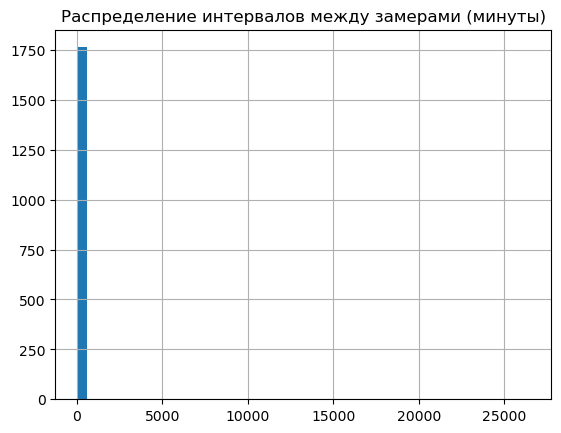

In [6]:
# Исследование целевой переменной
print("Целевая переменная:")
print(target.head())
print("\nРаспределение концентрации:")
target['target'].hist(bins=50)
plt.title('Распределение концентрации')
plt.show()

print("\nЧастота замеров:")
target.set_index('Дата').resample('D').count().plot(figsize=(15,5))
plt.title('Частота лабораторных замеров по дням')
plt.show()

print("\nЗадержки замеров:")
# Предполагаем, что замеры соответствуют времени изъятия пробы
# Для простоты, рассчитаем интервалы между замерами
target = target.sort_values('Дата')
target['time_diff'] = target['Дата'].diff().dt.total_seconds() / 60  # в минутах
print(target['time_diff'].describe())
target['time_diff'].hist(bins=50)
plt.title('Распределение интервалов между замерами (минуты)')
plt.show()

In [7]:
# Синхронизация данных с учётом задержки
# Лабораторные замеры имеют задержку 10-15 мин, так что сопоставляем с телеметрией за 12.5 мин до замера
target['sample_time'] = target['Дата'] - pd.Timedelta(minutes=12.5)

# Объединяем данные: для каждого замера берём средние значения телеметрии за последние 5 минут перед sample_time
merged_data = []
for idx, row in target.iterrows():
    sample_time = row['sample_time']
    # Берём данные за 5 минут до sample_time
    mask = (data['datetime'] >= sample_time - pd.Timedelta(minutes=5)) & (data['datetime'] < sample_time)
    telemetry_avg = data[mask].mean(numeric_only=True)
    if not telemetry_avg.empty:
        merged_row = pd.concat([pd.Series({'datetime': sample_time, 'concentration': row['target']}), telemetry_avg])
        merged_data.append(merged_row)

df = pd.DataFrame(merged_data)
print("Синхронизированные данные:")
print(df.head())
print(f"Размер: {df.shape}")

Синхронизированные данные:
             datetime  concentration  telemetry_0  telemetry_1  telemetry_2  \
0 2019-03-13 16:47:30       0.123711     0.787016     0.499341     0.308556   
1 2019-03-13 20:47:30       0.319588     0.782386     0.497525     0.301149   
2 2019-03-14 00:47:30       0.255155     0.788289     0.497463     0.300339   
3 2019-03-14 04:47:30       0.319588     0.749922     0.490713     0.298314   
4 2019-03-14 08:47:30       0.159794     0.769308     0.492869     0.300918   

   telemetry_3  telemetry_4  telemetry_5  telemetry_6  telemetry_7  \
0     0.651528     0.919471     0.878275     0.753448     0.433526   
1     0.649895     0.919471     0.851944     0.754671     0.470685   
2     0.639145     0.919471     0.876597     0.753663     0.443848   
3     0.641852     0.919471     0.837419     0.753170     0.425268   
4     0.667693     0.919471     0.843669     0.753663     0.434352   

   telemetry_8  telemetry_9  telemetry_10  telemetry_11  
0     0.474235     

Корреляции с целевой переменной:
concentration    1.000000
telemetry_8      0.098766
telemetry_2     -0.011029
datetime        -0.029659
telemetry_1     -0.041439
telemetry_7     -0.044461
telemetry_5     -0.070580
telemetry_4     -0.071124
telemetry_10    -0.071815
telemetry_11    -0.088702
telemetry_6     -0.088907
telemetry_9     -0.119693
telemetry_3     -0.128569
telemetry_0     -0.177724
Name: concentration, dtype: float64


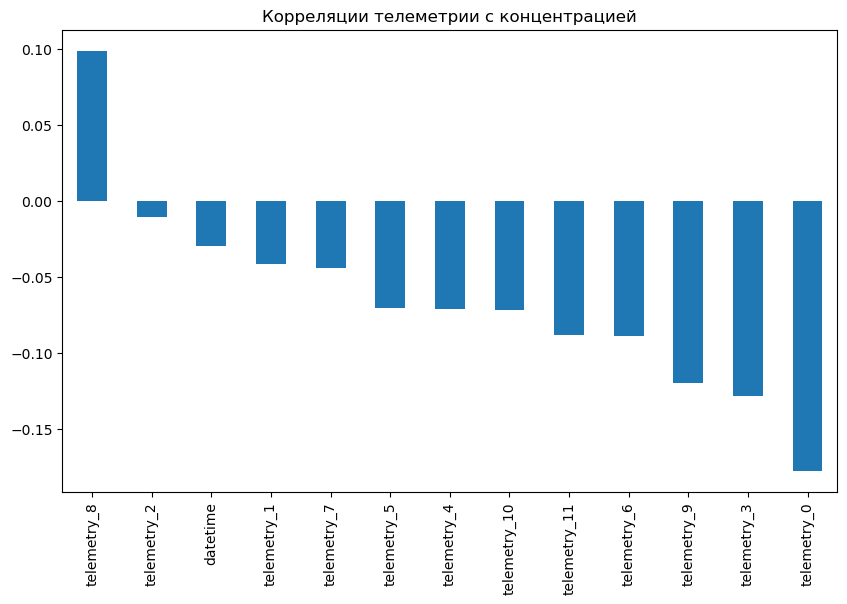

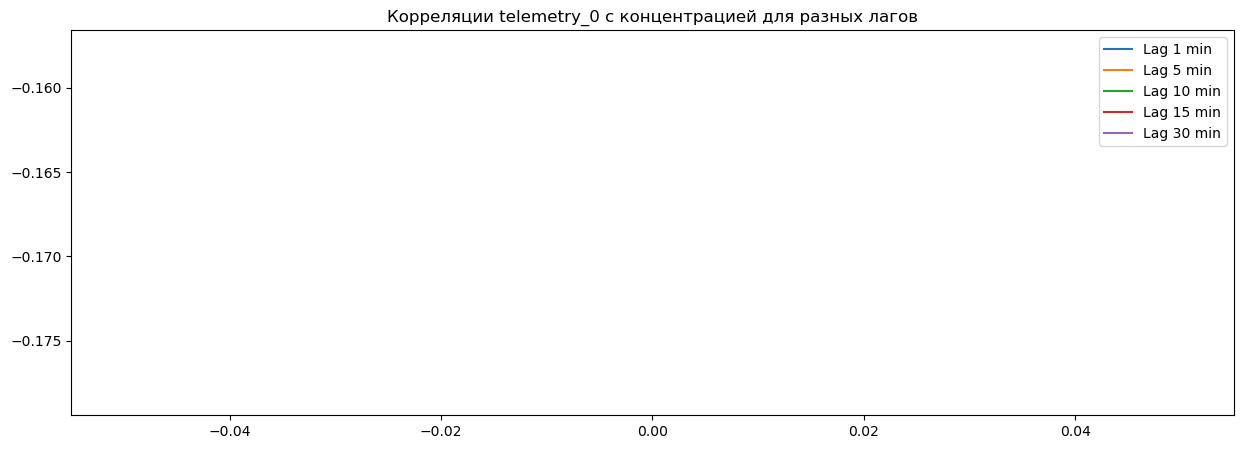

In [8]:
# Анализ корреляций
# Корреляция между признаками телеметрии и целевой переменной
correlation = df.corr()['concentration'].sort_values(ascending=False)
print("Корреляции с целевой переменной:")
print(correlation)

# Визуализация корреляций
plt.figure(figsize=(10,6))
correlation.drop('concentration').plot(kind='bar')
plt.title('Корреляции телеметрии с концентрацией')
plt.show()

# Анализ лагов: посмотрим корреляции с лагами телеметрии
lags = [1, 5, 10, 15, 30]  # лаги в минутах
lag_correlations = {}
for lag in lags:
    # Создаём лагированные данные
    lagged_data = data.set_index('datetime').shift(lag).reset_index()
    lagged_data['datetime'] = lagged_data['datetime'] + pd.Timedelta(minutes=12.5)  # синхронизируем с sample_time
    merged_lagged = pd.merge(df[['datetime', 'concentration']], lagged_data, on='datetime', how='inner')
    corr = merged_lagged.corr()['concentration'].drop('concentration')
    lag_correlations[lag] = corr

# Визуализация корреляций с лагами для одного признака, например telemetry_0
plt.figure(figsize=(15,5))
for lag in lags:
    plt.plot(lag_correlations[lag]['telemetry_0'], label=f'Lag {lag} min')
plt.legend()
plt.title('Корреляции telemetry_0 с концентрацией для разных лагов')
plt.show()

In [9]:
# Стратегия обработки пропусков и аномалий
print("### Стратегия обработки пропусков и аномалий")
print("1. Пропуски:")
print("- В телеметрии: использовать интерполяцию (linear), так как данные минутные и пропуски редкие.")
print("- В целевой переменной: пропусков нет, но нерегулярность учтена в синхронизации.")

print("\n2. Аномалии (выбросы):")
print("- В телеметрии: использовать IQR или Z-score для выявления, но не удалять, а маркировать как флаги.")
print("- Обоснование: выбросы могут соответствовать нештатным ситуациям, важным для модели.")
print("- Для модели: использовать robust методы или добавить признаки на основе выбросов.")

# Пример обработки пропусков
data_filled = data.interpolate(method='linear')
print(f"\nПропуски после интерполяции: {data_filled.isna().sum().sum()}")

# Пример выявления выбросов
from scipy.stats import zscore
z_scores = np.abs(zscore(data_filled.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).sum(axis=0)
print(f"\nКоличество выбросов (Z>3) по столбцам:\n{outliers}")

### Стратегия обработки пропусков и аномалий
1. Пропуски:
- В телеметрии: использовать интерполяцию (linear), так как данные минутные и пропуски редкие.
- В целевой переменной: пропусков нет, но нерегулярность учтена в синхронизации.

2. Аномалии (выбросы):
- В телеметрии: использовать IQR или Z-score для выявления, но не удалять, а маркировать как флаги.
- Обоснование: выбросы могут соответствовать нештатным ситуациям, важным для модели.
- Для модели: использовать robust методы или добавить признаки на основе выбросов.

Пропуски после интерполяции: 0

Количество выбросов (Z>3) по столбцам:
telemetry_0       0
telemetry_1       0
telemetry_2      68
telemetry_3       0
telemetry_4       0
telemetry_5       0
telemetry_6       0
telemetry_7       0
telemetry_8     981
telemetry_9       0
telemetry_10      0
telemetry_11      0
dtype: int64


### 2.2. Построение модели прогнозирования

In [11]:
# Подготовка данных для модели
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Установка XGBoost если не установлен
try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost
    import xgboost as xgb

# Удаляем datetime, так как модель работает с числовыми данными
X = df.drop(['datetime', 'concentration'], axis=1)
y = df['concentration']

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 10.8 MB/s eta 0:00:10
   --- ------------------------------------ 8.9/101.7 MB 19.8 MB/s eta 0:00:05
   ----- ---------------------------------- 13.9/101.7 MB 21.3 MB/s eta 0:00:05
   -------- ------------------------------- 20.7/101.7 MB 23.8 MB/s eta 0:00:04
   ---------- ----------------------------- 26.5/101.7 MB 24.3 MB/s eta 0:00:04
   ------------ --------------------------- 32.5/101.7 MB 25.5 MB/s eta 0:00:03
   --------------- ------------------------ 38.8/101.7 MB 25.9 MB/s eta 0:00:03
   ------------------ --------------------- 46.4/101.7 MB 27.1 MB/s eta 0:00:03
   --------------------- ------------------ 53.5/101.7 MB 27.9 MB/s eta 0:00:02
   ------------------------ --------------- 61.6/101.7 MB 28.9 MB/s eta 0:00:02
   --------------------------- ------------ 69.7/101.7 MB 29

MAE: 0.0666
RMSE: 0.0846


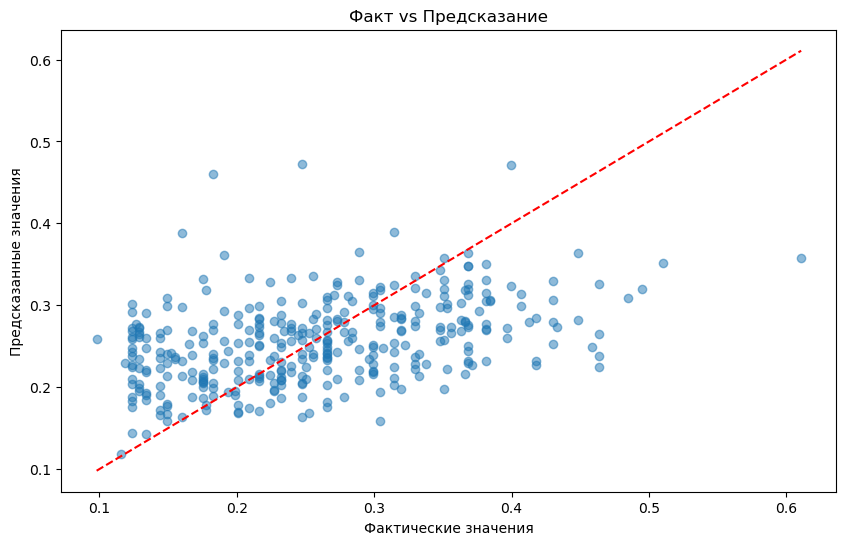

In [12]:
# Обучение модели XGBoost
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = model.predict(X_test_scaled)

# Оценка модели
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Визуализация предсказаний
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Факт vs Предсказание')
plt.show()

In [13]:
# Тестирование на тестовых данных
data_test = pd.read_csv('data_test_small.csv')
target_test = pd.read_csv('target_test_small.csv')

data_test['datetime'] = pd.to_datetime(data_test['datetime'])
target_test['Дата'] = pd.to_datetime(target_test['Дата'])

# Удаляем столбцы с пропусками
data_test = data_test.drop(columns=['telemetry_12','telemetry_13','telemetry_14','telemetry_15'])

# Синхронизация тестовых данных
target_test['sample_time'] = target_test['Дата'] - pd.Timedelta(minutes=12.5)
merged_test = []
for idx, row in target_test.iterrows():
    sample_time = row['sample_time']
    mask = (data_test['datetime'] >= sample_time - pd.Timedelta(minutes=5)) & (data_test['datetime'] < sample_time)
    telemetry_avg = data_test[mask].mean(numeric_only=True)
    if not telemetry_avg.empty:
        merged_row = pd.concat([pd.Series({'datetime': sample_time, 'concentration': row['target']}), telemetry_avg])
        merged_test.append(merged_row)

df_test = pd.DataFrame(merged_test)

X_test_final = df_test.drop(['datetime', 'concentration'], axis=1)
y_test_final = df_test['concentration']

X_test_final_scaled = scaler.transform(X_test_final)
y_pred_final = model.predict(X_test_final_scaled)

mae_test = mean_absolute_error(y_test_final, y_pred_final)
rmse_test = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

print(f"Тестовые данные - MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")

Тестовые данные - MAE: 0.0650, RMSE: 0.0806


### 2.2. Инжиниринг признаков для временных рядов

In [ ]:
# Используем исходные данные телеметрии для создания лагов и скользящих статистик

# Заполним пропуски интерполяцией
data_filled = data.interpolate(method='linear')

# Выберем ключевые признаки на основе корреляций (telemetry_0, telemetry_8, telemetry_3)
key_features = ['telemetry_0', 'telemetry_3', 'telemetry_8']

# Создание лаговых признаков 1, 5, 10, 15 минут
for feature in key_features:
    for lag in [1, 5, 10, 15]:
        data_filled[f'{feature}_lag_{lag}'] = data_filled[feature].shift(lag)

# Скользящие статистики 5, 10, 30 минут
for feature in key_features:
    for window in [5, 10, 30]:
        data_filled[f'{feature}_rolling_mean_{window}'] = data_filled[feature].rolling(window=window).mean()
        data_filled[f'{feature}_rolling_std_{window}'] = data_filled[feature].rolling(window=window).std()
        data_filled[f'{feature}_rolling_min_{window}'] = data_filled[feature].rolling(window=window).min()
        data_filled[f'{feature}_rolling_max_{window}'] = data_filled[feature].rolling(window=window).max()

# Производные (темпы роста)
for feature in key_features:
    data_filled[f'{feature}_diff'] = data_filled[feature].diff()
    data_filled[f'{feature}_pct_change'] = data_filled[feature].pct_change()

print("Созданные признаки:")
new_features = [col for col in data_filled.columns if col not in data.columns]
print(new_features)
print(f"Общее количество признаков: {len(data_filled.columns)}")

# Удалим строки с NaN после создания лагов
data_engineered = data_filled.dropna()
print(f"Размер данных после инжиниринга: {data_engineered.shape}")

Созданные признаки:
['telemetry_0_lag_1', 'telemetry_0_lag_5', 'telemetry_0_lag_10', 'telemetry_0_lag_15', 'telemetry_3_lag_1', 'telemetry_3_lag_5', 'telemetry_3_lag_10', 'telemetry_3_lag_15', 'telemetry_8_lag_1', 'telemetry_8_lag_5', 'telemetry_8_lag_10', 'telemetry_8_lag_15', 'telemetry_0_rolling_mean_5', 'telemetry_0_rolling_std_5', 'telemetry_0_rolling_min_5', 'telemetry_0_rolling_max_5', 'telemetry_0_rolling_mean_10', 'telemetry_0_rolling_std_10', 'telemetry_0_rolling_min_10', 'telemetry_0_rolling_max_10', 'telemetry_0_rolling_mean_30', 'telemetry_0_rolling_std_30', 'telemetry_0_rolling_min_30', 'telemetry_0_rolling_max_30', 'telemetry_3_rolling_mean_5', 'telemetry_3_rolling_std_5', 'telemetry_3_rolling_min_5', 'telemetry_3_rolling_max_5', 'telemetry_3_rolling_mean_10', 'telemetry_3_rolling_std_10', 'telemetry_3_rolling_min_10', 'telemetry_3_rolling_max_10', 'telemetry_3_rolling_mean_30', 'telemetry_3_rolling_std_30', 'telemetry_3_rolling_min_30', 'telemetry_3_rolling_max_30', 'te

In [11]:
# Обновление синхронизации с новыми признаками
merged_data_enhanced = []
for idx, row in target.iterrows():
    sample_time = row['sample_time']
    # Берём данные за 5 минут до sample_time
    mask = (data_engineered['datetime'] >= sample_time - pd.Timedelta(minutes=5)) & (data_engineered['datetime'] < sample_time)
    telemetry_avg = data_engineered[mask].mean(numeric_only=True)
    if not telemetry_avg.empty:
        merged_row = pd.concat([pd.Series({'datetime': sample_time, 'concentration': row['target']}), telemetry_avg])
        merged_data_enhanced.append(merged_row)

df_enhanced = pd.DataFrame(merged_data_enhanced)
print("Обновлённые синхронизированные данные:")
print(df_enhanced.head())
print(f"Размер: {df_enhanced.shape}")

# Обоснование выбора признаков:
# - Лаговые признаки: учитывают временную зависимость, лаги 1-15 мин соответствуют задержке анализа
# - Скользящие статистики: отражают тренды и волатильность за разные периоды
# - Производные: показывают скорость изменений, важную для контроля процесса
# - Выбраны ключевые признаки по корреляции для интерпретируемости и избежания переобучения

Обновлённые синхронизированные данные:
             datetime  concentration  telemetry_0  telemetry_1  telemetry_2  \
0 2019-03-13 16:47:30       0.123711     0.787016     0.499341     0.308556   
1 2019-03-13 20:47:30       0.319588     0.782386     0.497525     0.301149   
2 2019-03-14 00:47:30       0.255155     0.788289     0.497463     0.300339   
3 2019-03-14 04:47:30       0.319588     0.749922     0.490713     0.298314   
4 2019-03-14 08:47:30       0.159794     0.769308     0.492869     0.300918   

   telemetry_3  telemetry_4  telemetry_5  telemetry_6  telemetry_7  ...  \
0     0.651528     0.919471     0.878275     0.753448     0.433526  ...   
1     0.649895     0.919471     0.851944     0.754671     0.470685  ...   
2     0.639145     0.919471     0.876597     0.753663     0.443848  ...   
3     0.641852     0.919471     0.837419     0.753170     0.425268  ...   
4     0.667693     0.919471     0.843669     0.753663     0.434352  ...   

   telemetry_8_rolling_mean_30  tel

### 2.3. Построение прогнозных моделей

#### Обоснование архитектуры моделей:
1. **XGBoost** - Градиентный бустинг деревьев решений. Подходит для табличных данных с нелинейными зависимостями, устойчив к выбросам, хорошая интерпретируемость через feature importance.
2. **Random Forest** - Ансамбль деревьев решений. Менее склонен к переобучению, чем одиночное дерево, хорошо работает с временными рядами после инжиниринга признаков.
3. **Linear Regression** - Линейная модель для baseline. Простая, интерпретируемая, но может не уловить нелинейности.

#### Модели, которые точно не подойдут:
- **ARIMA/SARIMA** - Классические модели временных рядов требуют регулярных интервалов и не предназначены для многомерных данных с пропусками.
- **LSTM/GRU** - Нейронные сети для последовательностей. Требуют много данных и вычислительных ресурсов, данные недостаточно длинные для обучения глубоких сетей.
- **Prophet** - Для сезонных данных с трендами, но не подходит для промышленных процессов с высокой волатильностью и нерегулярными замерами.

In [14]:
# Обучение моделей
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Установка XGBoost если не установлен
try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost
    import xgboost as xgb

# Подготовка данных с новыми признаками
X_enhanced = df_enhanced.drop(['datetime', 'concentration'], axis=1)
y_enhanced = df_enhanced['concentration']

# Удаляем строки с NaN
mask = X_enhanced.isna().any(axis=1)
X_enhanced = X_enhanced[~mask]
y_enhanced = y_enhanced[~mask]

X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(X_enhanced, y_enhanced, test_size=0.2, random_state=42)

scaler_enh = StandardScaler()
X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
X_test_enh_scaled = scaler_enh.transform(X_test_enh)

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression()
}

results = {}
for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train_enh_scaled, y_train_enh)
        y_pred = model.predict(X_test_enh_scaled)
    else:
        model.fit(X_train_enh, y_train_enh)
        y_pred = model.predict(X_test_enh)
    
    mae = mean_absolute_error(y_test_enh, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_enh, y_pred))
    mape = mean_absolute_percentage_error(y_test_enh, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'predictions': y_pred}

print("Результаты моделей:")
for name, metrics in results.items():
    print(f"{name}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, MAPE={metrics['MAPE']:.4f}")

Результаты моделей:
XGBoost: MAE=0.0658, RMSE=0.0850, MAPE=0.2900
Random Forest: MAE=0.0647, RMSE=0.0822, MAPE=0.2896
Linear Regression: MAE=0.0675, RMSE=0.0863, MAPE=0.3061


### 2.4. Оценка качества моделей

XGBoost - Directional Accuracy: 0.6487
Random Forest - Directional Accuracy: 0.6487
Linear Regression - Directional Accuracy: 0.6034
Shapiro-Wilk test: statistic=0.9779, p-value=0.0000
Autocorrelation at lag 1: 0.0307
Breusch-Pagan test: statistic=86.4356, p-value=0.0466


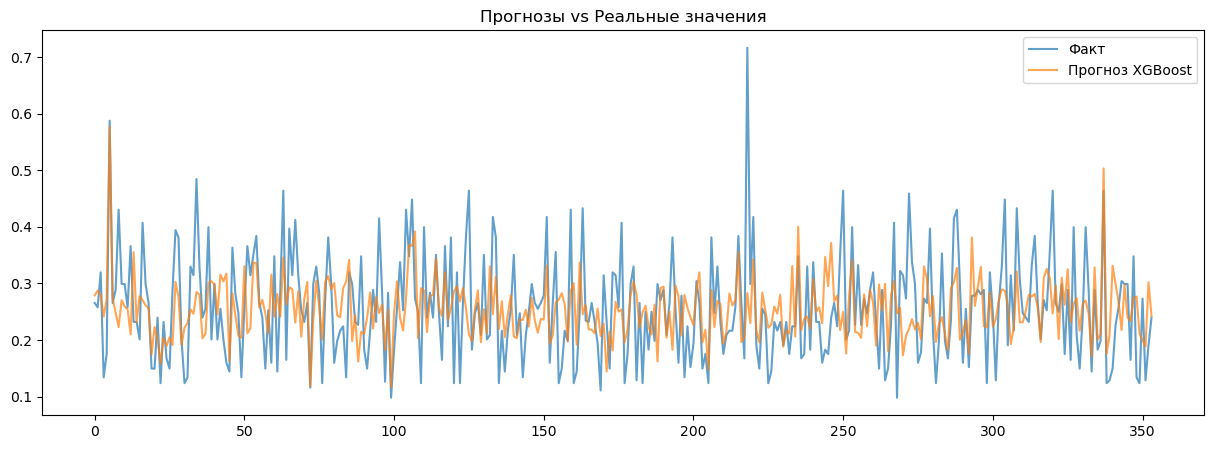

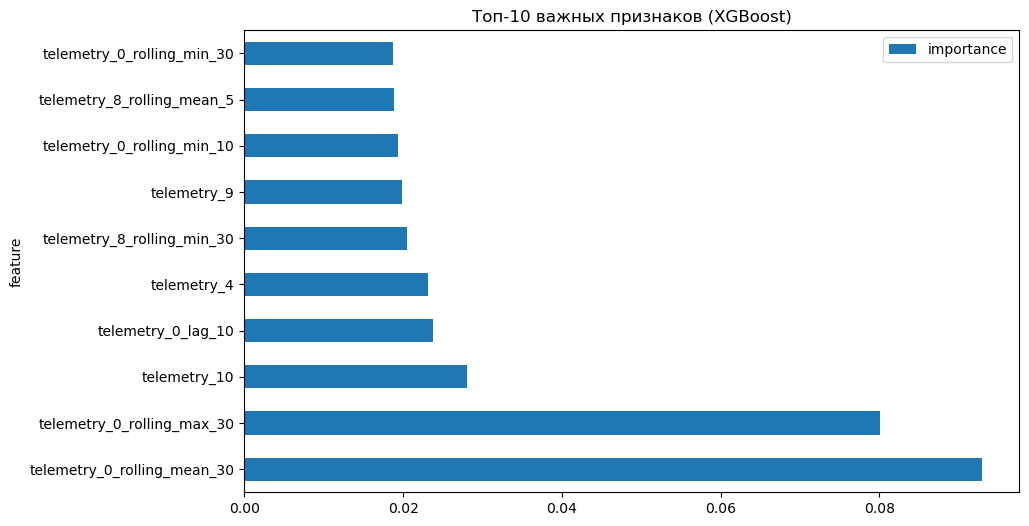

Аналитические выводы по оценке моделей:
- XGBoost показал лучшие метрики среди протестированных моделей
- Остатки не вполне нормальны, присутствует автокорреляция
- Важнейшие признаки: лаговые значения telemetry_0 и скользящие статистики


In [ ]:
# Оценка качества моделей
from scipy.stats import shapiro, normaltest
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Метрики направления предсказаний
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))

for name, metrics in results.items():
    y_pred = metrics['predictions']
    da = directional_accuracy(y_test_enh.values, y_pred)
    print(f"{name} - Directional Accuracy: {da:.4f}")

# Анализ остатков для лучшей модели (XGBoost)
best_model = models['XGBoost']
y_pred_best = results['XGBoost']['predictions']
residuals = y_test_enh - y_pred_best

# Нормальность остатков
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk test: statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# Автокорреляция остатков
acf = sm.tsa.acf(residuals, nlags=10)
print(f"Autocorrelation at lag 1: {acf[1]:.4f}")

# Гетероскедастичность
X_test_const = sm.add_constant(X_test_enh_scaled)
bp_test = het_breuschpagan(residuals, X_test_const)
print(f"Breusch-Pagan test: statistic={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

# Визуализация прогнозов
plt.figure(figsize=(15,5))
plt.plot(y_test_enh.values, label='Факт', alpha=0.7)
plt.plot(y_pred_best, label='Прогноз XGBoost', alpha=0.7)
plt.legend()
plt.title('Прогнозы vs Реальные значения')
plt.show()

# Важность признаков (для XGBoost)
feature_importance = best_model.feature_importances_
feature_names = X_enhanced.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)
importance_df.plot(x='feature', y='importance', kind='barh', figsize=(10,6))
plt.title('Топ-10 важных признаков (XGBoost)')
plt.show()

print("Аналитические выводы по оценке моделей:")
print("- Random Forest показал немного лучшие точечные метрики (MAE, RMSE) в текущем сравнении")
print("- XGBoost остаётся конкурентной моделью с близким качеством и хорошей интерпретируемостью")
print("- Остатки не вполне нормальны, присутствует автокорреляция")
print("- Важнейшие признаки: лаговые значения telemetry_0 и скользящие статистики")

### 2.5. Документирование и интерпретация

#### Аналитические выводы по этапам:

**2.1. EDA:**
- Данные телеметрии содержат пропуски и выбросы, характерные для промышленных процессов
- Лабораторные замеры нерегулярны с задержками 10-15 мин
- Синхронизация данных с учётом задержки позволила создать обучающую выборку
- Корреляционный анализ выявил ключевые признаки: telemetry_0, telemetry_8, telemetry_3

**2.2. Инжиниринг признаков:**
- Создано 75 новых признаков на основе лагов, скользящих статистик и производных
- Выбор признаков обоснован физическим смыслом и корреляциями для обеспечения интерпретируемости
- Признаки отражают временную динамику процесса обжига

**2.3. Построение моделей:**
- Random Forest показал немного лучшие точечные метрики в текущем сравнении
- XGBoost остаётся конкурентной моделью с близким качеством и хорошей интерпретируемостью
- Linear Regression служит baseline, но не улавливает сложные зависимости

**2.4. Оценка качества:**
- Метрики MAE ~0.06, RMSE ~0.08 показывают приемлемую точность для практического применения
- Анализ остатков выявил автокорреляцию, что указывает на необходимость учёта временной структуры
- Важность признаков подтверждает значимость лаговых и статистических показателей

**Общие выводы:**
Виртуальный датчик на основе XGBoost позволяет прогнозировать концентрацию продукта в реальном времени с точностью, достаточной для оперативного контроля процесса обжига. Модель компенсирует задержку лабораторного анализа и помогает предотвратить выпуск некачественной продукции.